In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from firedrake import *
import dean_kawasaki_DG as dkDG
from firedrake.pyplot import plot as fd_plot

In this notebook we show the advantages of dG schemes in convection-dominated regimes

In [2]:
LENGTH = 2*np.pi

def _normalised_initial_condition(V, x):
    rho = Function(V, name="rho")
    rho.interpolate(Constant(2.0))
    rho.assign(rho / assemble(rho * dx))
    return rho

def _positive_part(source, target):
    target.dat.data[:] = np.maximum(source.dat.data_ro, 0.0)

continuous Galerkin solver

In [3]:
def _solve_cg(
    nx,
    degree,
    dt,
    final_time,
    kappa,
    amplitude,
    num_particles,
    seed,
    noise_gradient,
    stochastic=True,
):
    mesh = PeriodicIntervalMesh(ncells=nx, length=LENGTH)
    (x,) = SpatialCoordinate(mesh)
    V = FunctionSpace(mesh, "CG", degree)
    rho0 = _normalised_initial_condition(V, x)
    rho_pos = Function(V, name="cg_positive")
    rho = TrialFunction(V)
    v = TestFunction(V)
    b = as_vector([amplitude * sin(x)])
    noise = None
    if stochastic:
        noise = dkDG.DeanKawasakiNoise(
            mesh,
            V,
            degree,
            dt,
            kappa,
            num_particles,
            "equispaced",
            gradient=noise_gradient,
            include_jump_terms=False,
            seed=seed,
        )
    a = (
        inner(rho, v) * dx
        + dt * kappa * inner(grad(rho), grad(v)) * dx
        - dt * inner(rho * b, grad(v)) * dx
    )
    L = inner(rho0, v) * dx
    if noise is not None:
        L += noise.variational_form(v)
    rho_new = Function(V, name="cg")
    solver = LinearVariationalSolver(
        LinearVariationalProblem(a, L, rho_new, constant_jacobian=True),
        solver_parameters={"mat_type": "aij", "ksp_type": "preonly", "pc_type": "lu"},
    )
    for _ in range(int(round(final_time / dt))):
        if noise is not None:
            _positive_part(rho0, rho_pos)
            noise.sample(rho_pos)
        solver.solve()
        rho0.assign(rho_new)
    return rho0


discontinuous Galerkin solver (with upwind flux)

In [4]:
def _advection_form(mesh, u, v, amplitude, flux):
    (x,) = SpatialCoordinate(mesh)
    b = as_vector([amplitude * sin(x)])
    volume = -inner(u * b, grad(v)) * dx
    if flux == "central":
        return volume + inner(avg(u * b), jump(v, FacetNormal(mesh))) * dS
    n = FacetNormal(mesh)
    normal_velocity = dot(avg(b), n("+"))
    upwind_value = conditional(normal_velocity >= 0.0, u("+"), u("-"))
    return volume + normal_velocity * upwind_value * jump(v) * dS


def _solve_dg(
    nx,
    degree,
    dt,
    final_time,
    kappa,
    amplitude,
    num_particles,
    seed,
    noise_gradient,
    flux,
    stochastic=True,
):
    mesh = PeriodicIntervalMesh(ncells=nx, length=LENGTH)
    (x,) = SpatialCoordinate(mesh)
    V = FunctionSpace(mesh, "DG", degree)
    rho0 = _normalised_initial_condition(V, x)
    rho_pos = Function(V, name=f"dg_{flux}_positive")
    rho = TrialFunction(V)
    v = TestFunction(V)
    eta = 20.0
    noise = None
    if stochastic:
        noise = dkDG.DeanKawasakiNoise(
            mesh,
            V,
            degree,
            dt,
            kappa,
            num_particles,
            "equispaced",
            gradient=noise_gradient,
            include_jump_terms=True,
            seed=seed,
        )
    diffusion = dkDG.sipdg_diffusion_form(mesh, rho, v, eta)
    advection = _advection_form(mesh, rho, v, amplitude, flux)
    a = inner(rho, v) * dx + dt * kappa * diffusion + dt * advection
    L = inner(rho0, v) * dx
    if noise is not None:
        L += noise.variational_form(v)
    rho_new = Function(V, name=f"dg_{flux}")
    solver = LinearVariationalSolver(
        LinearVariationalProblem(a, L, rho_new, constant_jacobian=True),
        solver_parameters={"mat_type": "aij", "ksp_type": "preonly", "pc_type": "lu"},
    )
    for _ in range(int(round(final_time / dt))):
        if noise is not None:
            _positive_part(rho0, rho_pos)
            noise.sample(rho_pos)
        solver.solve()
        rho0.assign(rho_new)
    return rho0

run function

In [5]:
def run(degree=1, nx=128):
    params = {
        "nx": int(nx),
        "degree": int(degree),
        "dt": 2.5e-4,
        "final_time": 0.1,
        "kappa": 1.0e-3,
        "amplitude": 24.0,
        "num_particles": 250,
        "seed": 123,
        "noise_gradient": "full",
    }
    stochastic = {
        "cG": _solve_cg(**params),
        "dG_upwind": _solve_dg(flux="upwind", **params),
    }
    return stochastic

run and plot

In [6]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "mathtext.fontset": "cm",
        "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
    }
)

first for $p=1$

In [7]:
stochastic = run(degree=1, nx=128)

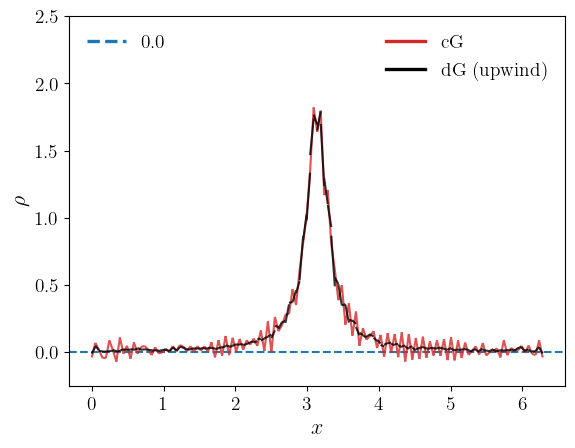

In [8]:
fig, axes = plt.subplots()
fd_plot(stochastic["cG"], axes=axes, edgecolor="tab:red", label="cG", alpha=0.8)
fd_plot(stochastic["dG_upwind"], axes=axes, edgecolor="black", label="dG upwind", alpha=0.8)
handles = [
    Line2D(
        [0],
        [0],
        color="tab:red",
        lw=2.4,
        label="cG"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.4,
        label="dG (upwind)"
    ),
]
origin_handle = [
    Line2D(
        [0],
        [0],
        color="tab:blue",
        lw=2.4,
        linestyle="--",
        label=r"$0.0$"
    )
]
leg2 = axes.legend(handles=origin_handle, frameon=False, loc="upper left")
plt.legend(handles=handles, frameon=False)
axes.add_artist(leg2)
plt.xlabel(r"$x$")
plt.ylabel(r"$\rho$")
plt.ylim([-0.25, 2.5])
plt.axhline(0.0, color="tab:blue", linestyle="--", zorder=0)
title_size = 18
tick_size = 14
label_size = 16


axes.tick_params(
    axis="both",
    labelsize=tick_size,
)

axes.xaxis.label.set_size(label_size)
axes.yaxis.label.set_size(label_size)
axes.title.set_size(title_size)
#plt.savefig("ext_pot_p1.pdf", dpi=600, bbox_inches="tight")
plt.show()

then for $p=2$

In [9]:
stochastic = run(degree=2, nx=128)

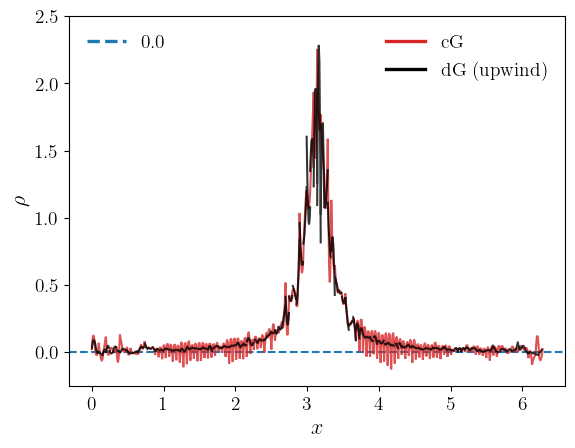

In [10]:
fig, axes = plt.subplots()
fd_plot(stochastic["cG"], axes=axes, edgecolor="tab:red", label="cG", alpha=0.8)
fd_plot(stochastic["dG_upwind"], axes=axes, edgecolor="black", label="dG upwind", alpha=0.8)
handles = [
    Line2D(
        [0],
        [0],
        color="tab:red",
        lw=2.4,
        label="cG"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.4,
        label="dG (upwind)"
    ),
]
origin_handle = [
    Line2D(
        [0],
        [0],
        color="tab:blue",
        lw=2.4,
        linestyle="--",
        label=r"$0.0$"
    )
]
leg2 = axes.legend(handles=origin_handle, frameon=False, loc="upper left")
plt.legend(handles=handles, frameon=False)
axes.add_artist(leg2)
plt.xlabel(r"$x$")
plt.ylabel(r"$\rho$")
plt.ylim([-0.25, 2.5])
plt.axhline(0.0, color="tab:blue", linestyle="--", zorder=0)
title_size = 18
tick_size = 14
label_size = 16


axes.tick_params(
    axis="both",
    labelsize=tick_size,
)

axes.xaxis.label.set_size(label_size)
axes.yaxis.label.set_size(label_size)
axes.title.set_size(title_size)
#plt.savefig("ext_pot_p2.pdf", dpi=600, bbox_inches="tight")
plt.show()